<a href="https://colab.research.google.com/github/miajags/EMSC2010-Mia-s-Individual-Project/blob/main/Individual_Final_Project_u7496742_FWs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Individual Project: Will the Superb Fairy-wren go extinct? The National Bird Index and Climate Variables**

## Project Overview

EMSC2010 Assessment 3

Name: Mia Jaggers, u7496742

Project title: Will the Superb Fairy-wren go extinct? The National Bird Index and Climate Variables.

Datasets used (name and source):
- Indexes of relative abundance of Australia's threatened and near-threatened species, Australian Bureau of Statistics (ABS). [Link](https://www.abs.gov.au/statistics/measuring-what-matters/measuring-what-matters-themes-and-indicators/sustainable/biological-diversity).
- Many small climate change impacts presage rapid population extinction in a common iconic bird, 'Population.data.csv', Lv et al., 2026. [Link](https://zenodo.org/records/18298289)
- Observed Climatology of Temperature and Precipitation Australia, The World Bank Group, 2026. [Link](https://climateknowledgeportal.worldbank.org/country/australia/climate-data-historical)

# Introduction

The **Superb Fairy-wren** (*Malurus cyaneus*) is a much-loved common Australian bird species. It's distribution ranges along Eastern Australia in QLD, NSW, ACT, VIC, TAS, and SA. The Superb Fairy-wren (FW) holds an **IUCN Red List Status of 'Least Concern'**, and is not part of the Threatened or Near-Threatened categories. The FW population trend is reported as Stable ([here](https://www.iucnredlist.org/species/22703736/253995896)).

A recent study ([Lv et al., 2026](https://www.nature.com/articles/s41467-026-70758-9#Sec27)) designed a *population model* for FWs based on data from a local population at the Australian National Botanic Gardens (ANBG) in Canberra. The population model suggested a high risk of **Superb Fairy-wrens becoming extinct in the next 30-40 years, due to a variety of small-scale climate change impacts**.

National data from the Australian Threatened and Near-Threatened Species Index ([Index](https://tsx.org.au/)) determines the relative abundance of Threatened and Near-Threatened Species against a reference year (1985=1.0). The Index shows a negative species abundance trend across all species taxon. This includes a declining trend for the relative abundance of Threatened and Near-Threatened Bird Species in Australia (the National Bird Index).


---
**Aim**

In this NoteBook I will use skills taught in the course EMSC2010 to investigate claims from the Lv et al. paper that the Superb Fairy-wren will become extinct, despite it's IUCN Status of 'Least Concern'. I'll also investigate the relationship between common climate variables and national bird species abundance.
  
I will demonstrate the following techniques:

Regression (FW population predictive intervals and National Bird Index), Timeseries (general long-term climate trends in Australia), and Correlation (significant relationships between climate variables and bird species abundance).

---

**Data Methods**

Dataset 1 - Threatened and Near-Threatened Species Index
- Citation: ABS, 2025
- Source: https://www.abs.gov.au/statistics/measuring-what-matters/measuring-what-matters-themes-and-indicators/sustainable/biological-diversity


Dataset 2 - Fairy-wren data from ANBG
- Citation: Lv, L., Zhao, Q., Liu, Y. et al. Many small climate change impacts presage rapid population extinction in a common iconic bird. Nature Communications 17, 2711 (2026). https://doi.org/10.1038/
- Source: https://zenodo.org/records/18298289


Dataset 3 - Observed Climatology of Temperature and Precipitation Australia
- Citation: The World Bank Group, 2026
- Source: https://climateknowledgeportal.worldbank.org/country/australia/climate-data-historical


To investigate the research questions, datasets from a range of sources were identified. Data from government sources and peer reviewed articles were prioritised, but independent nonprofit groups were also used. Datasets were found online and copied into a seperate spreadsheet specific to this project, 'Mia_Project_Data.xlsx'. Sheet1 in 'Mia_Project_Data.xlsx' contains all metadata relating to each sheet. Data and variable descriptions are included in each sheet. The combined file was created for convenience of running the NoteBook, with FAIR data principles included.


---

### **Research Questions**

1. Is the local population of Superb Fairy-wrens at the ANBG trending towards extinction?

2. Are local FW population trends aligned or consistent with national abundance of threatened and near-threatened bird species (National Bird Index)?

3. Is there a relationship between climate variables like temperature and rainfall (climate change signifiers) and national bird species abundance?

4. What inferences can we make about Australian bird species abundance and population trends from this analysis?



---
**Additional Resources**

[Superb Fairywren ALA](
https://bie.ala.org.au/species/https://biodiversity.org.au/afd/taxa/ae56080e-4e73-457d-93a1-0be6a1d50f34)

[IUCN FWs](https://www.iucnredlist.org/species/22703736/253995896)

[ABC FW news article](https://www.abc.net.au/news/2026-04-01/fears-for-superb-fairy-wrens-as-experts-predict-extinction/106520198)


---


# Analysis

In [1]:
#import packages as needed
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling
import pymc as pm #for automated Bayesian inference
import arviz as az #for analysis of Bayesian models
from scipy.stats import pearsonr #for correlation coefficients

!pip install bambi #system command to install bambi package
import bambi as bmb #for automated Bayesian regression

!pip install mpld3 #for interactive scatter plots
import mpld3
import mpld3.plugins as plugins

import sys #to fix errors in pymc
!{sys.executable} -m pip uninstall pytensor numba -y
!{sys.executable} -m pip install pytensor numba

Found existing installation: pytensor 3.0.3
Uninstalling pytensor-3.0.3:
  Successfully uninstalled pytensor-3.0.3
Found existing installation: numba 0.65.1
Uninstalling numba-0.65.1:
  Successfully uninstalled numba-0.65.1
  Using cached pytensor-3.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached numba-0.65.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
Using cached pytensor-3.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (2.3 MB)
Using cached numba-0.65.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)


# National Bird Species Abundance and Local Fairy-wren Populations



## National Threatened and Near-Threatened Species Index

Upload the project data file 'Mia_Project_Data.xlsx' and use pandas to read in the first datasheet containing information about the Australian Threatened and Neart-Threatened Species Index.
The following cells:
* Read in the datasheet and create a dataframe
* Clean the dataframe and define values as numpy arrays
* Plot each of the Threatened and Near-Threatened Species Indexes by taxon (amphibians, birds, mammals, plants, all species)
* Plot each taxon together to display the total Index


In [2]:
#read in file
file = 'Mia_Project_Data.xlsx'
df_ni = pd.read_excel(file, sheet_name='TS_INDEX', header=1)
df = df_ni.iloc[:, 0:6] # Select columns from index 0 to 5 (columns 1-6 only)
df.head()

,Year,Amphibians,Birds,Mammals,Plants,All
0,1985,1.00,1.00,1.00,1.00,1.00
1,1986,0.91,0.98,1.28,0.96,1.04
2,1987,0.68,1.02,1.41,0.91,1.02
3,1988,0.55,1.04,1.30,0.87,0.95
4,1989,0.46,1.05,1.20,0.84,0.90


In [3]:
#defining terms and columns in dataframe

# Convert 'Year' to numeric, coercing errors to NaN, then drop rows with NaN in relevant columns
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df_cleaned = df.dropna(subset=['Year', 'Amphibians', 'Birds', 'Mammals', 'Plants', 'All']).copy()
df_cleaned['Year'] = df_cleaned['Year'].astype(int) # Convert year to integer after dropping NaNs

year = df_cleaned['Year'].values #get the year data as a numpy array
amph = df_cleaned['Amphibians'].values #get the amphibian data as a numpy array
bird = df_cleaned['Birds'].values #get the bird data as a numpy array
mamm = df_cleaned['Mammals'].values #get the mammal data as a numpy array
plant = df_cleaned['Plants'].values #get the plant data as a numpy array
all = df_cleaned['All'].values #get the all species data as a numpy array

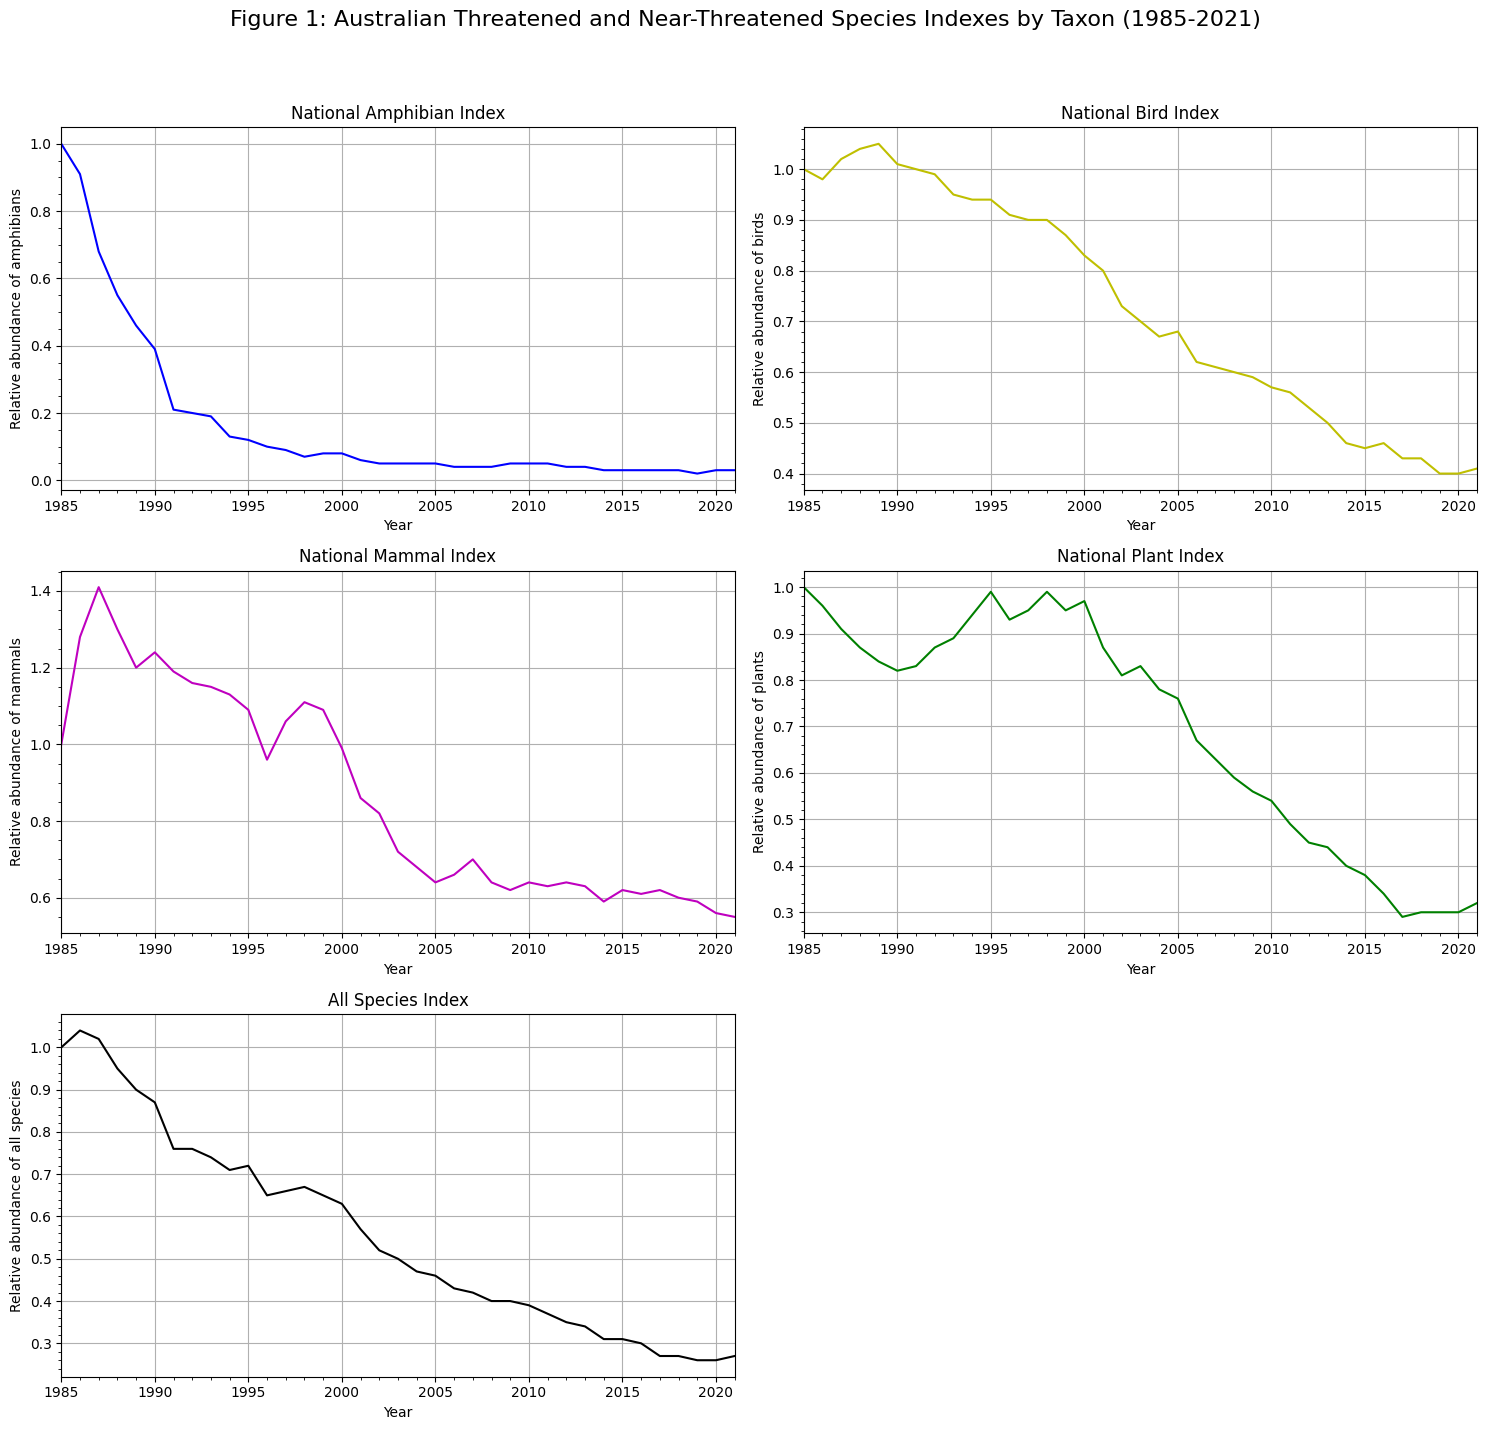

In [4]:
#plot index by year and each species taxon, and all species

fig, axes = plt.subplots(3, 2, figsize=(15, 15)) # Create a 3x2 grid of subplots
fig.suptitle('Figure 1: Australian Threatened and Near-Threatened Species Indexes by Taxon (1985-2021)', fontsize=16) # Overall title

# Redefine 'year' to match the length of the index data (amph, bird, etc.)
year_index = df_cleaned['Year'].values

# Amphibians
axes[0, 0].plot(year_index, amph,'b') #plot the data
axes[0, 0].set_xlabel('Year') #label the x-axis
axes[0, 0].set_ylabel('Relative abundance of amphibians') #label the y-axis
axes[0, 0].set_xlim(1985, 2021)
axes[0, 0].grid(True) #add a grid to the plot
axes[0, 0].minorticks_on() #add minor ticks to the plot
axes[0, 0].set_title('National Amphibian Index') #add a title to the plot

# Birds
axes[0, 1].plot(year_index, bird,'y') #plot the data
axes[0, 1].set_xlabel('Year') #label the x-axis
axes[0, 1].set_ylabel('Relative abundance of birds') #label the y-axis
axes[0, 1].set_xlim(1985, 2021)
axes[0, 1].grid(True) #add a grid to the plot
axes[0, 1].minorticks_on() #add minor ticks to the plot
axes[0, 1].set_title('National Bird Index') #add a title to the plot

# Mammals
axes[1, 0].plot(year_index, mamm,'m') #plot the data
axes[1, 0].set_xlabel('Year') #label the x-axis
axes[1, 0].set_ylabel('Relative abundance of mammals') #label the y-axis
axes[1, 0].set_xlim(1985, 2021)
axes[1, 0].grid(True) #add a grid to the plot
axes[1, 0].minorticks_on() #add minor ticks to the plot
axes[1, 0].set_title('National Mammal Index') #add a title to the plot

# Plants
axes[1, 1].plot(year_index, plant,'g') #plot the data
axes[1, 1].set_xlabel('Year') #label the x-axis
axes[1, 1].set_ylabel('Relative abundance of plants') #label the y-axis
axes[1, 1].set_xlim(1985, 2021)
axes[1, 1].grid(True) #add a grid to the plot
axes[1, 1].minorticks_on() #add minor ticks to the plot
axes[1, 1].set_title('National Plant Index') #add a title to the plot

# All Species
axes[2, 0].plot(year_index, all, 'k') #plot data
axes[2, 0].set_xlabel('Year') #label the x-axis
axes[2, 0].set_ylabel('Relative abundance of all species') #label the y-axis
axes[2, 0].set_xlim(1985, 2021)
axes[2, 0].grid(True) #add a grid to the plot
axes[2, 0].minorticks_on() #add minor ticks to the plot
axes[2, 0].set_title('All Species Index') #add a title to the plot

# Hide the unused subplot at axes[2, 1]
axes[2, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent labels from being cut off
plt.show() #show the plot

### *Figure 1: Australian Threatened and Near-Threatened Species Index by Taxon (1985-2021)*

Figure 1 displays 5 seperate plots of the Australian Threatened and Near-Threatened Species Index, catagorised by taxon. The plots show the relative abundance of threatened and near-threatened species in Australia is decreasing in reference to 1985 abundance levels. The National Mammal Index displays the only significant increase in relative species abundance from the reference year 1985, before eventually decreasing around 1988. The Index emcompasses 39 years of national species abundance records.

The focus taxon for this project is shown in the `National Bird Index` plot.

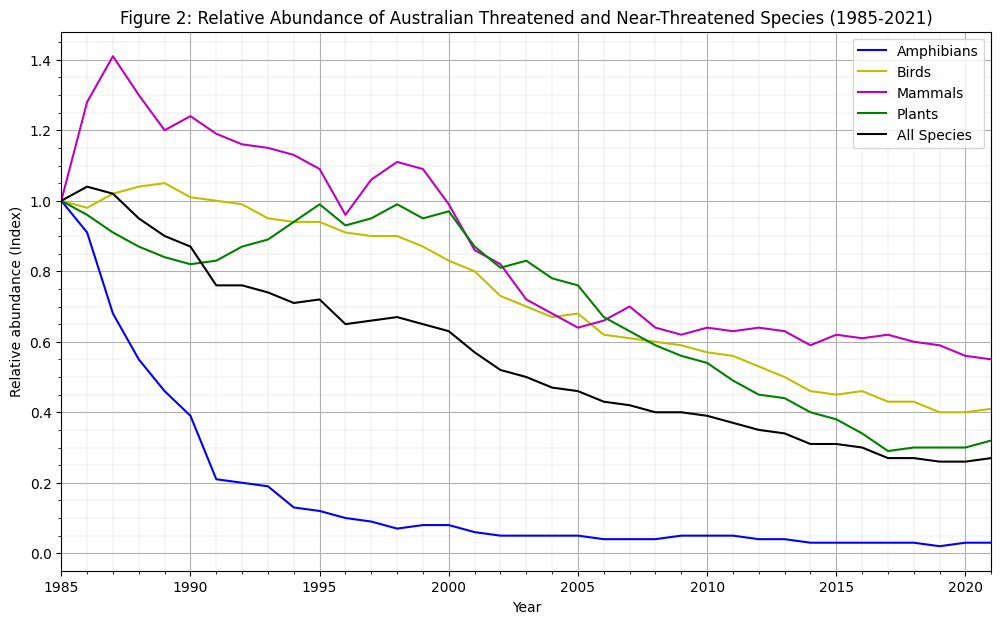

In [5]:
#plot all together
plt.figure(figsize=(12, 7))

# Re-assign 'year' from df_cleaned to ensure it has the correct dimensions for this plot
year = df_cleaned['Year'].values

plt.plot(year, amph, 'b', label='Amphibians')
plt.plot(year, bird, 'y', label='Birds')
plt.plot(year, mamm, 'm', label='Mammals')
plt.plot(year, plant, 'g', label='Plants')
plt.plot(year, all, 'k', label='All Species')

plt.xlabel('Year')
plt.ylabel('Relative abundance (Index)')
plt.title('Figure 2: Relative Abundance of Australian Threatened and Near-Threatened Species (1985-2021)')
plt.xlim(1985, 2021)
plt.grid(True)
plt.grid(True, which='minor', linestyle='-', linewidth='0.05', color='black')
plt.minorticks_on()
plt.legend()
plt.show()

### *Figure 2: Relative Abundance of Australian Threatened and Near-Threatened Species (1985-2021)*

Figure 2 demonstrates a national declining trend in the abundance of Threatened and Near-Threatened Species since 1985. A declining trend is similarly observed for the National Bird Index.

The below cell calculates the difference in relative species abundance from 1985 to 2021 for each taxon. The Index difference indicates that Threatened and Near-Threatened Bird Species abundance has decreased by 59%.

In [6]:
#index difference over 36 years
amph_change = 1 - amph[36]
bird_change = 1 - bird[36]
mamm_change = 1 - mamm[36]
plant_change = 1 - plant[36]
all_change = 1 - all[36]

print(amph_change)
print(f"{bird_change:.2f}")
print(f"{mamm_change:.2f}")
print(f"{plant_change:.2f}")
print(all_change)

0.97
0.59
0.45
0.68
0.73


## Superb Fairy-wrens at the ANBG

To investigate claims from the [Lv et al.](https://www.nature.com/articles/nature01096) paper that Superb Fairy-wrens (FW) will become extinct, I will utilise the paper's population dataset for FWs at the Australian National Botanic Gardens (ANBG). The ANBG local population has been recorded comprehensively since 1993-present. It is important to note that FW population data used for this project refers to the recorded number of Male and Female FWs at the ANBG on November 15th from 1993-2021.

The local FW population will be used to investigate if the National Bird Index `trends` for Threatened and Near-Threatened species is aligned or consistent with identified Least Concern status species (the Superb Fairy-wren).

To conduct this analysis, the National Bird Index and FW population will be scaled and plotted together for visual comparison of trends. By applying a regression model to the FW population data and identifying the predictive 95% Highest Density Interval (HDI), I can observe population trends of FWs at the ANBG and **assess if they are heading towards extinction**. Overlaying a scaled version of the National Bird Index to the predictive 95% HDI for the FW population will show if **national abundance trends for Threatened and Near-Threatened, and Least Concern species, are consistent**.

The following cells:
* Read in the ANBG FW population data and create a dataframe
* Create a cleaned dataframe with the Year, Male population, Female population, and Average population (coded using .mean function for male and female populations)
* Convert these values into numpy arrays
* Plot the Male, Female, and Average FW Population from 1993-2021



In [7]:
#read in sheet 3 with fairy-wren data
df_fw = pd.read_excel(file, sheet_name='FW_POP')
df2 = df_fw.iloc[:, 0:9] # Select columns from index 0 to 4 (columns 1-5 only)
df2.head()

,Year,Male.popu.Nov.15,Female.popu.Nov.15,#Juveniles.Apr.1,#Female.Juveniles.Apr.1,#Female.Natal.Juveniles.Apr.1,#Female.Juvenile.Immigrants.Apr.1,#Female.Immigrants.Nov.15,#Male.Immigrants.Nov.15
0,1993,181,87,106.0,39.0,34.0,12.0,NaN,NaN
1,1994,171,79,76.0,31.0,29.0,5.0,10.0,7.0
2,1995,148,73,121.0,44.0,40.0,25.0,14.0,1.0
3,1996,152,81,106.0,42.0,34.0,16.0,17.0,2.0
4,1997,137,82,81.0,28.0,23.0,12.0,9.0,4.0


In [8]:
#cleaned fairy-wren dataframe

df_fw = df2[['Year', 'Male.popu.Nov.15', 'Female.popu.Nov.15']].copy()
df_fw = df_fw.dropna() #remove rows with NaN missing values
year = df_fw['Year'].to_numpy() #convert years into numpy array
male_pop = df_fw['Male.popu.Nov.15'].to_numpy() #convert male population into numpy array
female_pop = df_fw['Female.popu.Nov.15'].to_numpy() #convert female population into numpy array
df_fw['average_pop'] = df_fw[['Male.popu.Nov.15', 'Female.popu.Nov.15']].mean(axis=1).astype(int) #create value for mean population
average_pop = df_fw['average_pop'].to_numpy() #convert new median into numpy array
df_fw.head() #show the header information

,Year,Male.popu.Nov.15,Female.popu.Nov.15,average_pop
0,1993,181,87,134
1,1994,171,79,125
2,1995,148,73,110
3,1996,152,81,116
4,1997,137,82,109


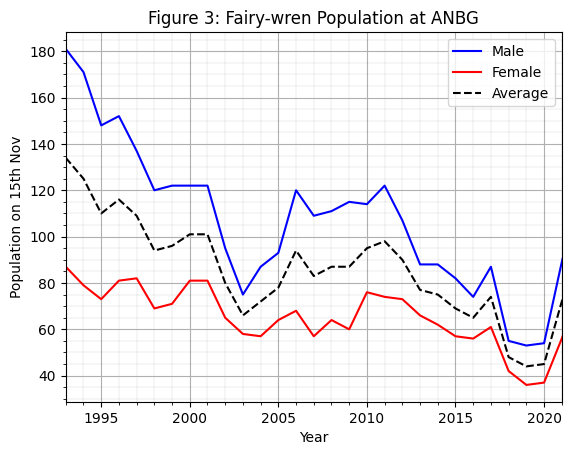

In [9]:
# Plot the male, female, and average population of Fairy wrens at the ANBG over time

plt.plot(year, male_pop, 'b', label='Male')
plt.plot(year, female_pop, 'r', label='Female')
plt.plot(year, average_pop, 'k', linestyle='--', label='Average')
plt.xlabel('Year')
plt.ylabel('Population on 15th Nov')
plt.title('Figure 3: Fairy-wren Population at ANBG')
plt.xlim(1993,2021)
plt.grid(True)
plt.grid(True, which='minor', linestyle='-', linewidth='0.05', color='black')
plt.minorticks_on()
plt.legend()
plt.show()

### *Figure 3: Fairy-wren Population at ANBG*

Figure 3 shows the Male, Female and Average population size of Superb Fairy-wrens at the ANBGs from 1993-2021. On average, there are more Males than Females in the FW population, although both sexes follow similar population trends. The Average FW population will be used for project analysis. Noteably, Figure 3 shows that Average FW population size at the ANBG is declining over the study period, with significant population peaks and troughs occurring in 2003, 2011 and 2021.

## Scaled National Bird Index and Superb Fairy-wren Population Trends

To visually compare the population trends of Fairy-wrens at the ANBG (representative of local scale population trends) and the National Bird Index (representative of large scale population trends), the data requires re-scaling or normalising.

Re-scaling the National Bird Index to show relative species abundance in reference to year 1993 (1993=1) will allow for direct comparison with the FW population data (because FW popultion data begins in 1993). The original Bird Index data is in reference to the year 1895. Similarly, normalising the Average Fairy-wren population data so population size at 1993 is scaled to 1, and each subsequent year plots the average FW population relative to 1993 (1993=1), will allow for direct comparison of the two variables.

A plot of the Normalised National Bird Index and Average Fairy-wren population data, in reference to 1993=1 is displayed below.


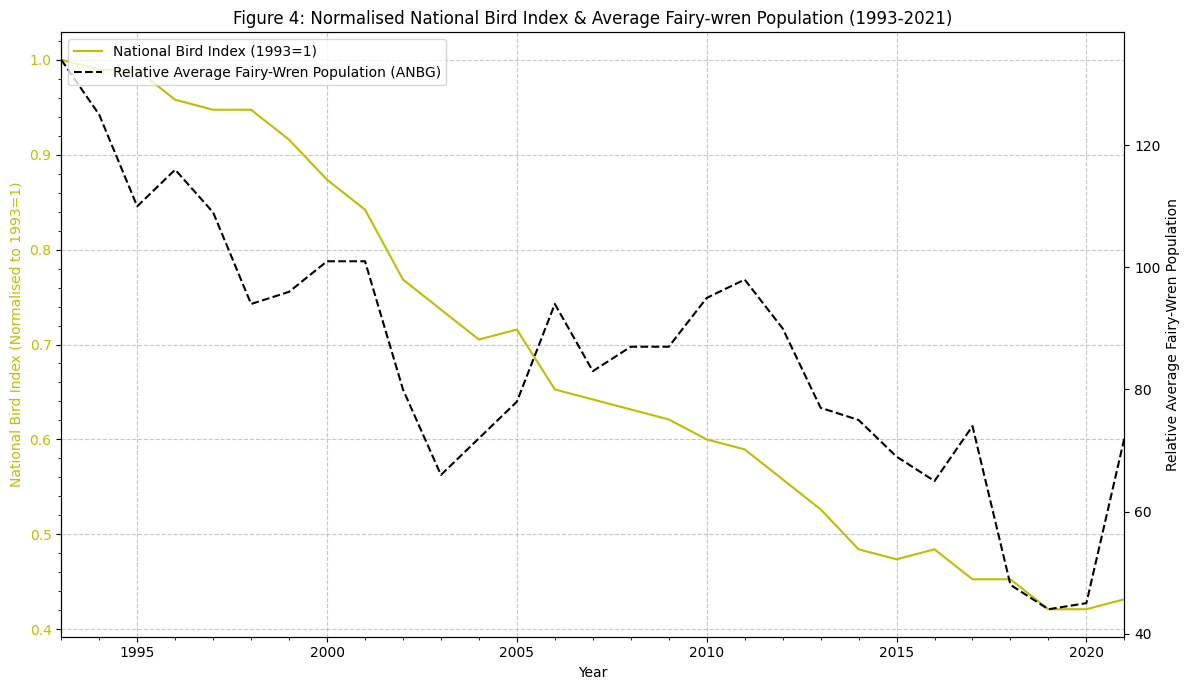

In [10]:
## Plot the National Bird Index (Normalized to the FW year range so 1993=1) and the FW average population against year, for comparison

# Filter Bird Index data for the desired year range (1993-2021)
year_bird_filtered = df_cleaned[(df_cleaned['Year'] >= 1993) & (df_cleaned['Year'] <= 2021)]['Year'].values
bird_filtered = df_cleaned[(df_cleaned['Year'] >= 1993) & (df_cleaned['Year'] <= 2021)]['Birds'].values

# Filter Fairy-Wren Population data for the desired year range (1993-2021)
year_fw_filtered = df_fw[(df_fw['Year'] >= 1993) & (df_fw['Year'] <= 2021)]['Year'].values
average_pop_filtered = df_fw[(df_fw['Year'] >= 1993) & (df_fw['Year'] <= 2021)]['average_pop'].values

# 1. Get the Bird Index value for 1993
bird_index_1993_value = df_cleaned[df_cleaned['Year'] == 1993]['Birds'].iloc[0]

# 2. Normalize the Bird Index data so that 1993 = 1
normalized_bird_index = bird_filtered / bird_index_1993_value

# Create a figure and a set of subplots with a dual y-axis
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot normalized Bird Index on the primary y-axis (ax1)
ax1.plot(year_bird_filtered, normalized_bird_index, 'y', label='National Bird Index (1993=1)')
ax1.set_xlabel('Year')
ax1.set_ylabel('National Bird Index (Normalised to 1993=1)', color='y')
ax1.tick_params(axis='y', labelcolor='y')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.minorticks_on()

# Create a second y-axis that shares the same x-axis (ax2)
ax2 = ax1.twinx()

# Plot average Fairy-Wren population on the secondary y-axis (ax2)
ax2.plot(year_fw_filtered, average_pop_filtered, 'k--', label='Relative Average Fairy-Wren Population (ANBG)')
ax2.set_ylabel('Relative Average Fairy-Wren Population', color='k')
ax2.tick_params(axis='y', labelcolor='k')

plt.title('Figure 4: Normalised National Bird Index & Average Fairy-wren Population (1993-2021)')
plt.xlim(1993, 2021)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### *Figure 4: Normalised National Bird Index & Average Fairy-wren Population (1993-2021)*

Figure 4 shows the **Normalized National Bird Index and Average Fairy-wren Population data appear to visually follow similar trends**. This relationship is interesting because it directly compares the species abundance/average population size of Threatened and Near-Threatened Species (which is expexted to be in decline, as seen in the Index), and a species of Least Concern (the FW).

A regression model is used to analyse the relationship between these trends.

# Regression Analysis for FW Population

To demonstrate how the National Bird Index and Average FW Population are related to one another (defining and quantifying the relationship), a regression model of the Average FW data will be analysed. A scaled version of the National Bird Index will be overlayed on the FW regression model. In theory, if the trends are **consistent** with one another, the National Bird Index should fall within **the ```95% High Density Interval (predictive)``` band for the Average FW Population**. This will determine if changes in the FW population are systematically related to changes in the National Bird Index, helping to understand if local population trends (FW) are indicative of broader national trends (National Bird Index).

First, the raw average FW data is plotted as a scatter plot.

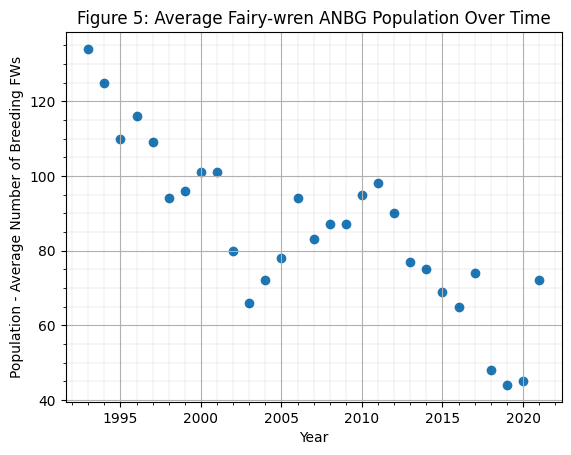

In [11]:
#plotting FW data as a scatter plot, year and average population

plt.scatter(year_fw_filtered, average_pop_filtered)
plt.xlabel('Year')
plt.ylabel('Population - Average Number of Breeding FWs')
plt.title('Figure 5: Average Fairy-wren ANBG Population Over Time')
plt.grid(True)
plt.grid(True, which='minor', linestyle='-', linewidth='0.05', color='black')
plt.minorticks_on()
plt.show()

### *Figure 5: Average Fairy-wren ANBG Population Over Time*

Figure 5 displays a scatter plot of the average Superb Fairy-wren population at the ANBG from 1993 to 2021. The plot visually appears to emmulate a negative linear trend.


### Extinction as an Exponential Function

To investigate if Fairy-wrens will go extinct (as predicted by the Lv et al. paper), there is an assumption that the data, when modelled, will be an exponential function. This is because if the population of FWs will eventually reach 0 (indicating extinction), the model must follow a ```negative exponential function```, where the local FW population decays until extinction (population=0).

### Justification for Natural Logarithm

To model the average FW population size as an exponential, a natural logarithm (log function) needs to be applied. If a population is decreasing exponentially, directly applying a linear regression model to the raw population data would not accurately capture this non-linear relationship. But, by taking the natural logarithm of the population data, an exponential decay can be transformed into a linear relationship. If the observed logged average FW population fits a negative slope, **it will demonstrate the population is exponentially decaying, and therefore will become extinct**.

In the below cell the natural log of the average FW population is plotted as a scatter plot.


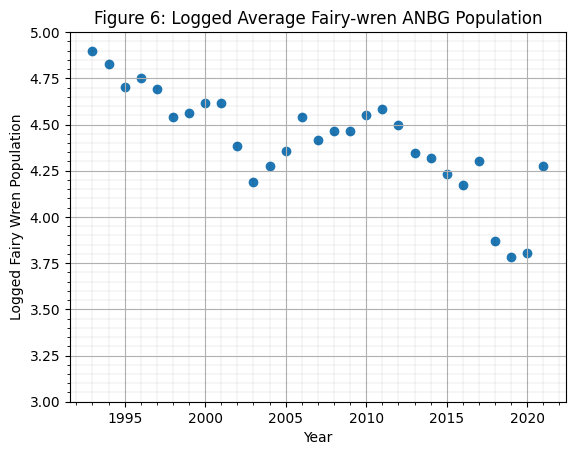

In [12]:
#take the log of average_pop_filtered
log_pop_data = np.log(average_pop_filtered)

#plot year and logged population data
plt.scatter(year_fw_filtered, log_pop_data)
plt.ylim(3, 5)
plt.xlabel('Year')
plt.ylabel('Logged Fairy Wren Population')
plt.title('Figure 6: Logged Average Fairy-wren ANBG Population')
plt.grid(True)
plt.grid(True, which='minor', linestyle='-', linewidth='0.05', color='black')
plt.minorticks_on()
plt.show()

### *Figure 6: Logged Average Fairy-wren ANBG Population*

Figure 6 displays a scatter plot of the natural logarithm of the average FW population size from 1993 to 2021. This transformation linearizes the population data, allowing for easier analysis of potential exponential decay trends. This visualises the linearized trend that is expected if FW populations are heading towards extinction.

### Regression Model of Logged Average FW Population

Conducting regression analysis of the logged average FW population data will reveal if a negative linear trend is evident. `95% HDI`s for the average and predictive posteriers will also be identified. This requires sampling of priors and posterior distributions according to `Bayes' Theorum`.

The below cell uses the `bmb` package to create appropriate priors and sample posterior distributions in a chain of 8. Priors and posterior distributions are plotted in the following cell.

In [13]:
#log linear
popdata = pd.DataFrame({"x": year_fw_filtered, "y": log_pop_data}) #put the data into a dataframe with variable names "x" and "y".
model = bmb.Model("y ~ x", popdata) #setup the first-order (linear) polynomial model
# ~ means y can be predicted by x (y function of x)

idata = model.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sampling posteriors

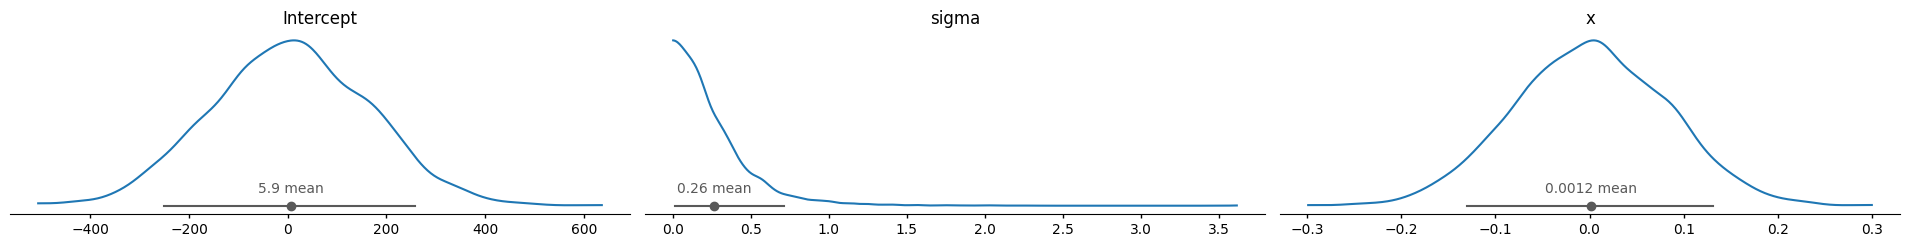

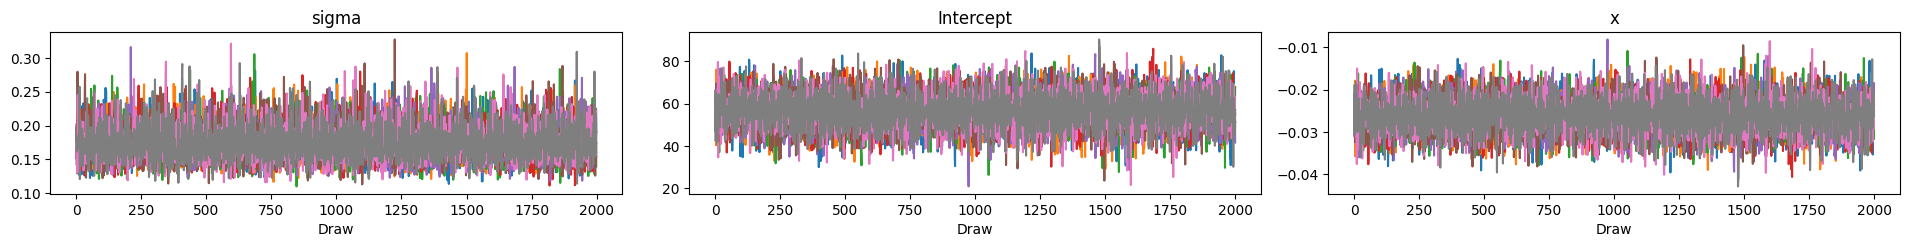

In [14]:
# plot priors
model.plot_priors()
plt.tight_layout()
plt.show()

# plot posterior distributions
az.plot_trace(idata);
plt.tight_layout() #this spaces the plots out so that they don't overlap

The above plots show the priors and posterior distributions. Overlapping colours in prosterior plots represent each Markov Monte Carlo chain (n=8). This shows the prosterior chains are converging and there is more confidence in results - the samples look promising.

### Plotting a Linear Regression Model for the Logged Average FW Population

The below cell comprehensively plots a linear regression model of the logged average FW population with relevant 95% HDIs. A scaled version of the National Bird Index will be overlayed on the regression analysis.

The regression plot includes:
* The raw logged average data points - 'Data'
* The linear regression model - 'FW Posterior Mean'
* The 95% HDI (Highest Density Interval) using the Intercept priors - 'FW 95% HDI average'
* The 95% HDI using the sigma priors - 'FW 95% HDI (predictive)'
* A scaled version of the National Bird Index where the first logged FW population value=1 - 'Scaled National Bird Index'

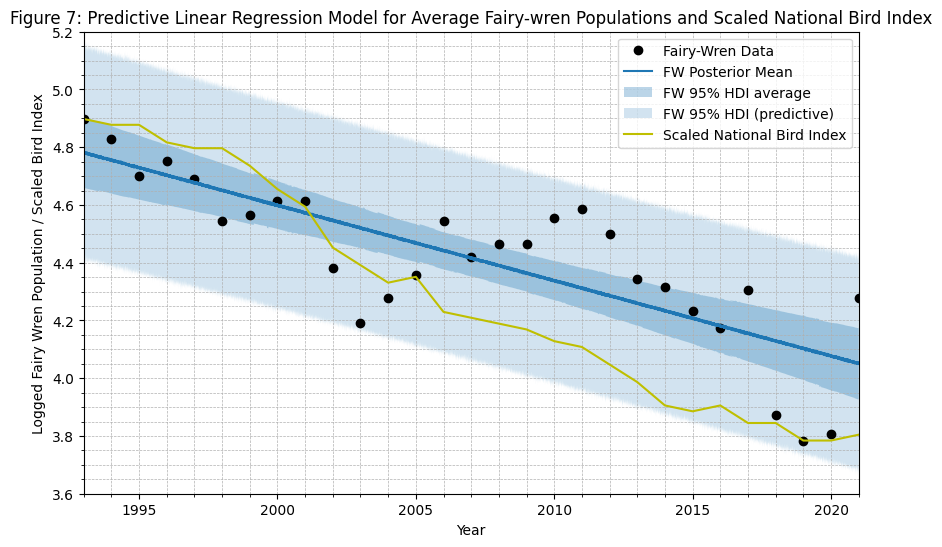

In [15]:
## Plot a linear regression model for the logged fairy wren population
# Plot original data points, intercept prior 95% ID (average), and sigma prior 95% HDI (predictive)

xrange = np.linspace(year_fw_filtered.min(), year_fw_filtered.max(), 16000) #x limit has to be 16000 to fit y values
new_data = pd.DataFrame({"x": xrange}) #dataframe with the new x-values

# Ensure both response_params (for hdi_mean) and response (for y_pps_draws) are predicted
model.predict(idata, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value
model.predict(idata, data=new_data, kind='response') #predict the posterior predictive distribution

# Make random draws from the posterior of the population size
y_pps_draws = idata.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(xrange))

# Compute mean and HDI of the posterior predictive distribution
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata.posterior["mu"].values.reshape(-1, len(xrange)), prob=0.95, axis=0)
hdi_pps = az.hdi(y_pps_draws, prob=0.95, axis=0)

# Calculate scaling parameters for the Bird Index
y_min_fw = log_pop_data.min()
y_max_fw = log_pop_data.max()
y_min_bird = bird_filtered.min()
y_max_bird = bird_filtered.max()

# Scale the Bird Index to fit the range of the logged Fairy-Wren population
scaled_bird_index = ((bird_filtered - y_min_bird) / (y_max_bird - y_min_bird)) * (y_max_fw - y_min_fw) + y_min_fw

# Plot both posterior for regression lines, and the observations
plt.figure(figsize=(10, 6))
plt.plot(year_fw_filtered, log_pop_data, 'ok', label="Fairy-Wren Data") #data/obersations
plt.plot(xrange, posterior_mean, color="C0", label="FW Posterior Mean") #posterior mean
plt.fill_between(
    xrange,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C0",
    label="FW 95% HDI average", #95% probability that the average population size will be in the HDI (intercept)
    edgecolor = None
)

plt.fill_between(
    xrange,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C0",
    label="FW 95% HDI (predictive)", #95% probability that predicted population size is in the HDI (sigma)
    edgecolor = None
)

# Plot the scaled National Bird Index
plt.plot(year_bird_filtered, scaled_bird_index, 'y', label='Scaled National Bird Index')

plt.legend() #tidy plot
plt.minorticks_on()
plt.xlim(1993, 2021) #set x limit
plt.ylim(3.6, 5.2) #set y limit
plt.xlabel('Year')
plt.ylabel('Logged Fairy Wren Population / Scaled Bird Index')
plt.title('Figure 7: Predictive Linear Regression Model for Average Fairy-wren Populations and Scaled National Bird Index')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### *Figure 7: Predictive Linear Regression Model for Average Fairy-wren Populations and Scaled National Bird Index*

Figure 7 shows a **negative linear regression model fits the logged average FW population size. This shows the local FW population trend is in exponential decay, indicating extinction.**

The ```posterior mean``` shows the linear regression model of Fairy-wren population sizes at the ANBG. A negetive linear relationship is evident for the logged average FW population. The `95% HDI average` band represents the 95% probability envelope for the mean FW population size at a given year. This HDI considers prosterior plots for the intercept. 95% HDI  average represents the credible range for the regression line.

The ```sigma``` posterior distribution, representing deviations in population size away from the regression line, is the ```95% HDI (predictive)``` band. The ```95% HDI (predictive)``` band represents the 95% probability envelope for the size of the population at a given year. Meaning, the average population size of FWs should fall within the HDI (predictive) band 95% of the time.

**Overlaying the Scaled National Bird Index**

By scaling the National Bird Index so relative abundance is in reference to the first logged average FW population value, the two variables can directly be compared. Figure 7 shows the national Bird Index trend is **not inconsistent** with population trends of Fairy-wrens at the ANBG. This is because the Scaled National Bird Index trend falls *within the 95% HDI (predictive) band* for average population size of Fairy-wrens at the ANBG. While the analysis can be interpreted to suggest that the National Bird Index is *not inconsistent* with FW population trends, there is not sufficient evidence (due to the small sample size of FWs at the ANBG) to suggest these trends are *consistent* with one another.



#### The model in Figure 7 demonstrates that Fairy-wren populations are constantly and exponentially decreasing, suggesting Fairy-wrens are heading towards extinction.
* **This analysis is consistent with the findings of the Lv et al. paper**.
* **This population trend is not inconsistent with the National Bird Index trend**.

---


# Climate Variables

To investigate research questions 3 and 4, 'is there a relationship between climate varaibles and national bird species abundance', long-term climate trends for Australia will have to be identified. Analysing long-term trends in common climate variables such as temperature and rainfall will inform the project discussion about the effects of climate change on bird species abundance in Australia.

The below cell extracts Australian climate data from 1901-2024 available in 'Mia_Project_Data.xlsx' into a dataframe.

In [16]:
#read in national climate datasheet
df_c = pd.read_excel(file, sheet_name='AUS_CLI')
df_cli = df_c.iloc[:, 0:5] # Select columns from index 0 to 4 (columns 1-5 only)
df_cli.head()

,Year,Average Maximum Surface Air Temperature (Annual Mean °C),Average Minimum Surface Air Temperature (Annual Mean °C),Average Mean Surface Air Temperature (Annual Mean °C),Precipitation (Annual Mean mm)
0,1901,28.73,14.35,21.51,425.94
1,1902,28.94,14.05,21.47,319.59
2,1903,28.29,14.12,21.18,524.13
3,1904,28.32,14.07,21.17,500.81
4,1905,28.47,13.89,21.16,363.88


### Visualising Mean Annual Surface Air Temperatures and Precipitation in Australia (1901-2024)

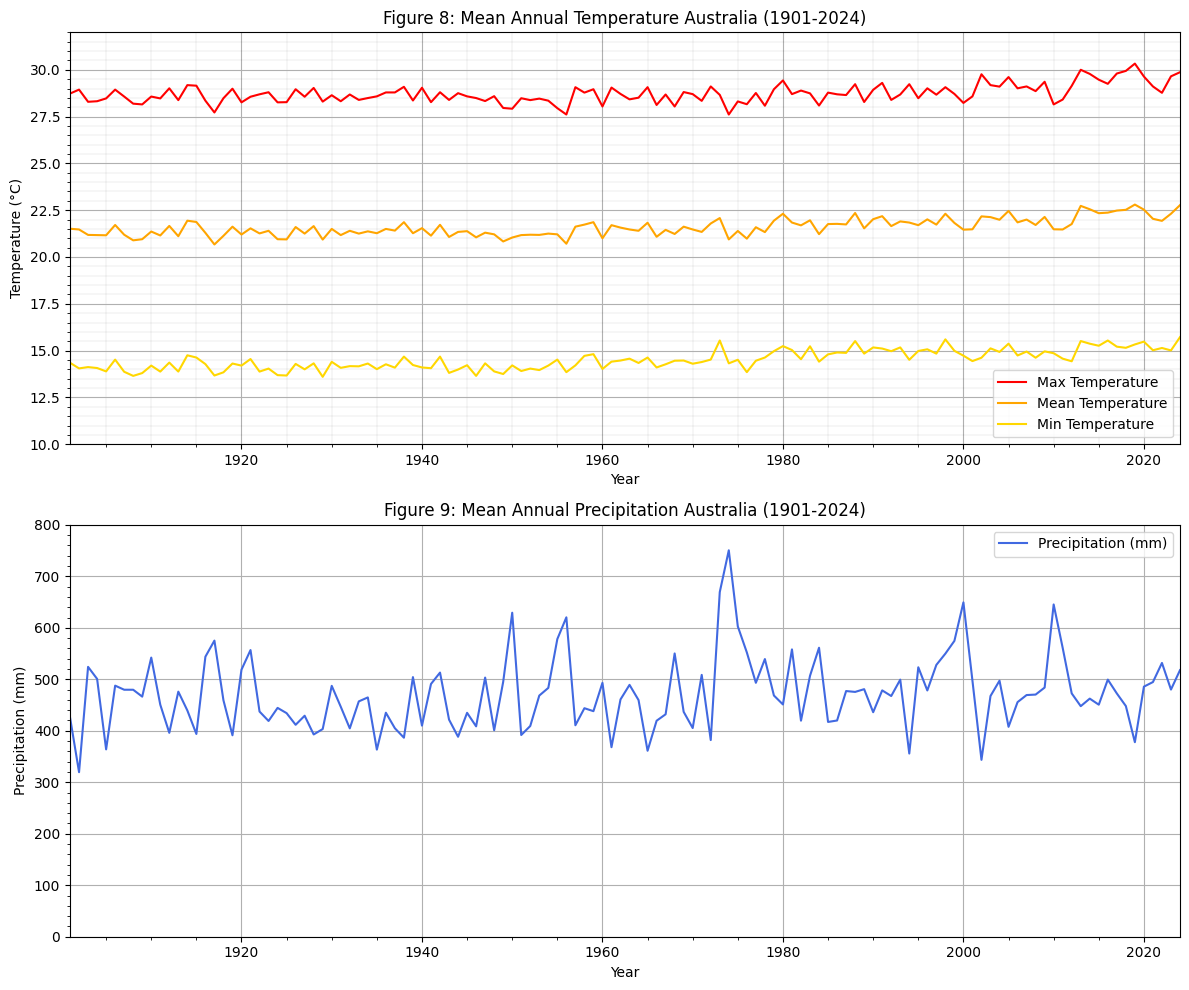

In [17]:
## turn dataframe values into numpy arrays
year = df_cli['Year'].to_numpy()
t_max = df_cli['Average Maximum Surface Air Temperature (Annual Mean °C)'].to_numpy()
t_min = df_cli['Average Minimum Surface Air Temperature (Annual Mean °C)'].to_numpy()
t_mean = df_cli['Average Mean Surface Air Temperature (Annual Mean °C)'].to_numpy()
prec = df_cli['Precipitation (Annual Mean mm)'].to_numpy()


## Make 2 plots, with temperature and precipitation data for years 1901-2024 in tight format

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Temperature plot
ax1.plot(year, t_max, color='red', label='Max Temperature') #plot max temp
ax1.plot(year, t_mean, color='orange', label='Mean Temperature') #plot mean temp
ax1.plot(year, t_min, color='gold', label='Min Temperature') #plot min temp
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature (°C)')
ax1.tick_params(labelbottom=True)
ax1.set_title('Figure 8: Mean Annual Temperature Australia (1901-2024)')
ax1.set_xlim(1901, 2024) #set axis limits
ax1.set_ylim(10, 32)
ax1.grid(True)
ax1.grid(True, which='minor', linestyle='-', linewidth='0.05', color='black')
ax1.minorticks_on()
ax1.legend()

# Precipitation plot
ax2.plot(year, prec, color='royalblue', label='Precipitation (mm)') #plot rainfall
ax2.set_xlabel('Year')
ax2.set_ylabel('Precipitation (mm)')
ax2.set_title('Figure 9: Mean Annual Precipitation Australia (1901-2024)')
ax2.set_xlim(1901, 2024) #set axis limits
ax2.set_ylim(0,800)
ax2.grid(True)
ax2.minorticks_on()
ax2.legend()

plt.tight_layout()
plt.show()

### *Figure 8: Mean Annual Temperature Australia (1901-2024)*

Figure 8 plots the maximum, mean, and minimum annaul temperatures in Australia from 1901 to 2024 (degrees Celsius). This is representative of the long-term national temperature data used for analysis.

### *Figure 9: Mean Annual Precipitation Australia (1901-2024)*

Figure 9 plots the mean annaul rainfall in Australia from 1901 to 2024 (degrees Celsius). This graph represents the long-term national precipitation data used for analysis.

### Moving Averages of Mean Annual Temperature and Rainfall Trends



To analyse long-term trends in the mean temperature and rainfall in Australia, a moving average will be applied to 'smooth' the data and allow for more accurate observations. By fitting a first-order polynomial trend (a linear model) to the data, generalised observations about long-term climate trends can be made.

Here the temperature and rainfall data is limited from 1901-2024 to 1985-2021, as this is the relevant period for later analysis and comparison with the National Bird Index (which ranges from 1985-2021). The parameter 'order = 1' was selected because first-order polynomials represent a linear function. This will visualise if there is a consistent trend in mean temperature and rainfall for Australia over the given period. The parameter 'w = 3' was used, as a moving average of 3 years for the period of 36 years seemed appropriate. The moving average was also determined by visually analysing the trendline, and therefore is subjective.

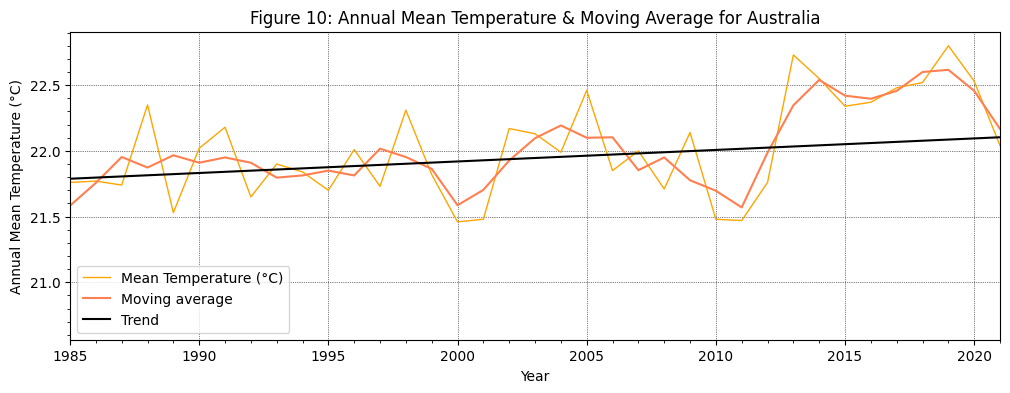

In [18]:
# Filter temperature data for the years 1985-2021 to match national bird index
t_mean_1985 = df_cli[(df_cli['Year'] >= 1985) & (df_cli['Year'] <= 2021)]['Average Mean Surface Air Temperature (Annual Mean °C)'].to_numpy()

##Plot Mean Temperature Data, Moving Average and Linear Trend

order = 1 #set the polynomial order
pp = np.polyfit(year,t_mean,order) #fit the polynomial
trend = np.polyval(pp,year) #find the value of the polynomial at each time point

def moving_average(t_mean,w):
  return np.convolve(t_mean, np.ones(w), 'valid') / w #moving average function

w = 3 #length of the moving average
p_t_mean = moving_average(t_mean, w) #process the mean temperature
p_year = moving_average(year, w) #process the time

plt.figure(figsize=(12, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,t_mean,'orange',linewidth=1,label='Mean Temperature (°C)') #plot mean temp data
plt.plot(p_year,p_t_mean,'coral',label='Moving average') #plot the moving average
plt.plot(year,trend,'k',label='Trend') #plot the trend
plt.xlim([1985,2021]) #limit the x-axis
plt.title('Figure 10: Annual Mean Temperature & Moving Average for Australia')
plt.xlabel('Year') #label the x-axis
plt.ylabel('Annual Mean Temperature (°C)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

### *Figure 10: Annual Mean Temperature & Moving Average for Australia*

The fitted first-order polynomial trend in Figure 10 shows that mean annual temperatures in Australia are consistently rising. This result is consistent with compounding evidence and general sentiments that global surface temperatures are rising due to climate change ([CSIRO](https://www.csiro.au/en/research/environmental-impacts/climate-change/state-of-the-climate/australias-changing-climate)).

The below calculation shows the combined average of mean temperatures from the period 1985-2021. It shows the mean temperature in Australia over the period is 22.02081°C.

In [19]:
t_mean_1985.mean() #find the average temperature across all years
print(t_mean_1985.mean())

22.02081081081081


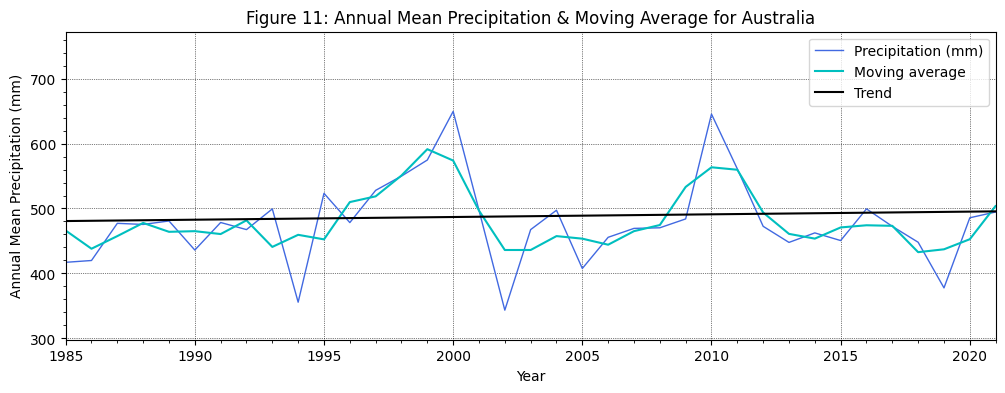

In [20]:
#Filter precipitation data for the years 1985-2021 to match national bird index
prec_1985 = df_cli[(df_cli['Year'] >= 1985) & (df_cli['Year'] <= 2021)]['Precipitation (Annual Mean mm)'].to_numpy()

##Plot Precipitation Data, Moving Average and Linear Trend

order2 = 1 #set the polynomial order
pp2 = np.polyfit(year,prec,order2) #fit the polynomial
trend2 = np.polyval(pp2,year) #find the value of the polynomial at each time point.

def moving_average(prec,w):
  return np.convolve(prec, np.ones(w), 'valid') / w #moving average function

w = 3 #length of the moving average
p_prec = moving_average(prec, w) #process the precipitation data
p_year = moving_average(year, w) #process the time

plt.figure(figsize=(12, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,prec,'royalblue',linewidth=1,label='Precipitation (mm)') #plot the prec data
plt.plot(p_year,p_prec,'c',label='Moving average') #plot the moving average
plt.plot(year,trend2,'k',label='Trend') #plot the trend
plt.xlim([1985,2021]) #limit the x-axis
plt.title('Figure 11: Annual Mean Precipitation & Moving Average for Australia')
plt.xlabel('Year') #label the x-axis
plt.ylabel('Annual Mean Precipitation (mm)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

### *Figure 11: Annual Precipitation & Moving Average for Australia*

The fitted first-order polynomial trend in Figure 11 shows annual precipitation in Australia is gradually increasing. This result is less compelling than the linear trend for mean temperature presented in Figure 10, as it is weaker. Rainfall around Australia also varies significantly by region and season, so generalised linear trends for rainfall will not comprehensively represent Australia's unique and varied climate systems.

The calculation shows the combined average precipitation from the period 1985-2021. It shows the mean precipitation in over the period is 478.96918mm.

In [21]:
prec_1985.mean()
print(prec_1985.mean())

478.9691891891892


# Investigating Relationships between Mean Annual Temperatures and the National Bird Index, and Annual Precipitation and the National Bird Index


The National Bird Index was previously scaled from it's original reference point to 1993 in order to directly compare it with Superb Fairy-wren population data (which ranged from 1993-2021). Using the original reference year where Threatened and Near-Threatened Species Adbundance is scaled so 1985=1.0, an analysis of possible relationships between the National Bird Index and long-term climate trends can be conducted.


## Scatter Plot: Mean Annual Temperature and National Bird Index

**By plotting the National Bird Index Species Abundance (1985-2021) on the x-axis and Mean Annual Temperature on the y-axis, potential trends between the two variables can be observed**.

 Importing package `mpld3` will create an interactive scatter plot, where hovering the mouse will display the year related to the value's Index score and temperature. Axis markers have been added to easily identify datapoints where Index and temperature varaibles are in [negative, negative], [negative, positive], [positive, negative], or [positive, positive] distributional relationships to each other. The axis markers are present, in yellow, at:
 * [x=0.5] = Middle point of the National Bird Index, which is scaled from 0 to 1.
 * [y=22.02081] = Calculated average of mean temperature data (see Figure 10 description).

In [22]:
## Create an interactive scatter plot for mean temperature (y axis) and bird index (x axis), in reference to year 1985

# The 't_mean_1985' filters mean temperature data from 1985-2021
# The 'bird' array already contains the National Bird Index from 1985-2021 (1985=1)
# The 'year_index' variable contains the years from 1985-2021

# Plot National Bird Index (x) and mean temperature (y)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(bird, t_mean_1985, color='k')

# Create tooltip labels with the year for each point
labels = [f"Year: {year_val}" for year_val in year_index]

# Create a tooltip plugin
tooltip = plugins.PointLabelTooltip(scatter, labels=labels)

# Add the tooltip plugin to the figure
plugins.connect(fig, tooltip)

ax.set_xlim(0.3, 1.1) # Adjust x-limit for the 1985=1 scaled bird index
ax.set_ylim(21, 23) # Keep y-limit consistent with temperature range
ax.set_xlabel('National Bird Index (1985=1)')
ax.set_ylabel('Annual Mean Temperature (°C)')
ax.set_title('Figure 12: National Bird Index (1985-2021) & Annual Mean Temperature')
ax.grid(True)
ax.minorticks_on()
plt.tight_layout()

#adding axis markers
plt.gca().axvline(x=0.5, color = 'orange', linestyle = '--') #add a vertical line at x=0.5 - middle of bird index
plt.gca().axhline(y=22.02081, color = 'orange', linestyle = '--') #add a horizontal line at y=22.02081 - mean of mean temp

mpld3.display(fig) # Use mpld3 to display the interactive plot

/usr/local/lib/python3.12/dist-packages/mpld3/mplexporter/exporter.py:84: UserWarning: Blended transforms not yet supported. Zoom behavior may not work as expected.
  warnings.warn("Blended transforms not yet supported. "


### *Figure 12: National Bird Index (1985-2021) and Annual Mean Temperature*

Figure 12 presents an interactive scatter plot illustrating the relationship between the National Bird Index (normalised to 1985=1) on the x-axis and the Annual Mean Temperature (°C) on the y-axis, spanning the period 1985 to 2021. A negative linear trend can be observed.


Visually, a discernible **negative trend** is observed in Figure 12. Data points are clustered in the bottom-right and top-left quadrants. Years with a higher National Bird Index correspond to lower mean annual temperatures (bottom-right quadrant, [negative, positive]). Conversely, years with a lower National Bird Index score correspond with higher mean annual temperatures in Australia (top-left quadrant, [positive, negative]). This indicates an inverse relationship, where mean annual temperatures increase, the National Bird Index tends to decrease.

It is crucial to note that years corresponding with increased mean annual temperature and lower National Bird Index scores are **all within the last two decades**. The interactive map shows a clear decade-divide in the relationship.
* Years with high temp, low National Bird Index: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021].
* Years with low temp, high National Bird Index: [1987, 1989, 1992, 1995, 1997, 2000, 2001].

These results are linked to the long-term climate trends observed in Figure 10. Mean Annual Temperatures in Australia are increasing over time, most likely due to climate change impacts, and **this is associated with declining National Bird Index scores**.

This negative lienar relationship has been visually suggested, but analysing the Correlation Coefficient between the two variables will define and quantify this relationship.


## Correlation of National Bird Index and Annual Mean Temperature

 Calculating the `Correlation coefficient` between the Normalized National Bird Index and Annual Mean Temperature will quantify the linear relationship between the two key variables, and determine if the relationship is statistically significant. A statistically significant correlation (especially if negative, given the declining National Bird Index and rising temperatures) would **provide evidence that average temperature changes are associated with national bird population trends**.

### Calculating and Plotting Deviations for National Bird Index and Mean Annual Temperature

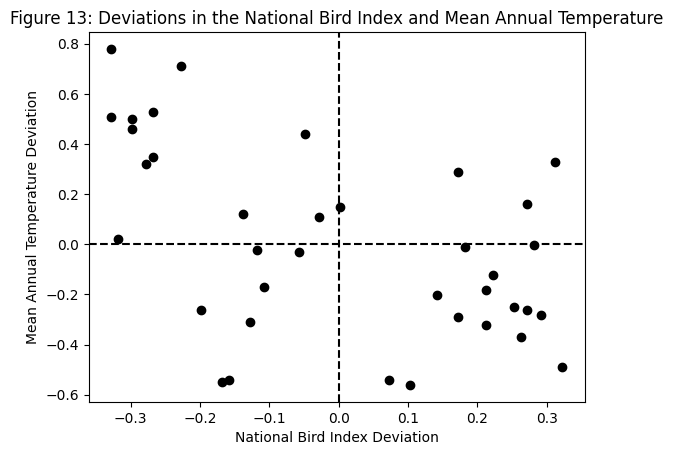

In [23]:
#calculate deviations for x and y variables
#x=bird, y=t_mean_1985, xb=bird deviation, yt=t_mean_1985 deviation

xb = bird - np.mean(bird) #deviation in the x variable
yt = t_mean_1985 - np.mean(t_mean_1985) #deviation in the y variable
plt.plot(xb , yt, 'ok') #plot deviations
plt.gca().axvline(x=0, color = 'k', linestyle = '--') #add a vertical line at x=0
plt.gca().axhline(y=0, color = 'k', linestyle = '--') #add a horizontal line at y=0
plt.xlabel('National Bird Index Deviation')
plt.ylabel('Mean Annual Temperature Deviation')
plt.title('Figure 13: Deviations in the National Bird Index and Mean Annual Temperature')
plt.show()

### *Figure 13: Deviations in the National Bird Index and Mean Annual Temperature*

Figure 13 shows the deviations in the National Bird Index and Mean Annual Temperature. Observations show a moderate negative linear trend, with some uncertainty. To calculate this relationship, a sample of `Pearson's r` correlation coefficient can be found. Pearson's $r$ is given by the following formula, which is applied in the following cell:

 $\frac{\Sigma x y}{\sqrt{\Sigma x^2} \sqrt{\Sigma y^2}}$

 ### Sample Pearson's r and P-Value for Mean Annual Temperature and National Bird Index Relationship

In [24]:
#equation to find pearson's correlation coefficient = r
num = np.sum(xb * yt) #find the numerator
den = np.sqrt(np.sum(xb**2)) * np.sqrt(np.sum(yt**2)) #find the denominator
r = num/den #obtain r
print('Sample Pearsons r = {:.2f}'.format(r)) #print result to 2 d.p.
print('squared r = {:.2f}'.format(r**2)) #print result to 2 d.p.

Sample Pearsons r = -0.50
squared r = 0.25


In [25]:
# Calculate the Pearson correlation coefficient and p-value
correlation_coefficient_temp_bird, p_value_temp_bird = pearsonr(bird, t_mean_1985)

print(f"Pearson Correlation Coefficient between National Bird Index and Annual Mean Temperature: {correlation_coefficient_temp_bird:.2f}")
print(f"P-value: {p_value_temp_bird:.3f}")

if p_value_temp_bird < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant at the 0.05 level.")

Pearson Correlation Coefficient between National Bird Index and Annual Mean Temperature: -0.50
P-value: 0.002
The correlation is statistically significant.


The calculations show the Sample Pearson's $r$ is **-0.50**.

This **proves a moderate negative linear relationship** between the National Bird Index and Annual Mean Temperature. A negative correlation means that as one variable increases (temperature), the other decreases (National Bird Index).

The `squared r` value is **0.25**. This means 25% of the variability in the National Bird Index can be explained by the Annual Mean Temperature. This also means that 75% of the variability in the National Bird Index is not explained by the Annual Mean Temperature, suggesting that other factors also influence the bird species abundance. This result is expected considering the range and complexity of climate change impacts on biodiversity, and multiple independent variables which can effect relative species abundance.

The second code cell re-calculates the `Sample Pearson's` $r$ using the `pearsonr` package to check results. The p-value is also calculated. The p-value helps determine the statistical significance of the correlation given by the `Sample Pearson's` $r$, indicated whether the observed relationship is likely due to chance or a genuine association between variables.

If the p-value is < 0.05, it indicates the relationship *is* statistically significant.

If the p-value is > 0.05, it indicates the relationship *is not* statistically significant.

The relationship for Mean Annual Temperature and the National Bird Index is **found to be significant with a p-value of 0.002**.

### Calculating Rho, the Covariance Matrix and 95% HDI for Correlation Coefficient

Calculating `rho` and the Convariance Matrix will allow sampling from the posterior distributions. Posterior distribution samples can be used to identify the `95% HDI` for rho.

`rho` or $p$ represents the population correlation coefficient, whereas the P-value (shown above as 0.002) is a sample estimate. The `95% HDI` for rho/$p$ represents the narrowest interval that contains 95% of the posterior probabilities. This 95% probability envelope provides a credible range for the value of `rho`, and will help determine if the correlation is statistically significant.

If the `95% HDI for rho` band includes 0, it indicates that the correlation *is not* statistically significant.

If the `95% HDI for rho` band does not include 0, it indicates that the correlation *is* statistically significant.

The following cells calculate rho, the covariance matrix, and the 95% HDI.

In [26]:
## combining bird and t_mean_1985 into a matrix (two-dimensional dataset) so it can be modelled

xbyt = np.column_stack([bird, t_mean_1985])

with pm.Model() as model: #define the PyMC model

    # Priors for means of the bivariate normal distribution
    mu = pm.Normal("mu", mu=0, sigma=5, shape=2)
    ## mean of x = 0, sd of x = 5, shape = we need two priors, one for x and one for y

    # Prior for correlation coefficient — uniform between -1 and 1
    rho = pm.Uniform("rho", lower=-1, upper=1)

    # Prior for standard deviations of the bivariate normal distribution
    sigma = pm.HalfNormal("sigma", sigma=2, shape=2, progressbar=False)
    ## half normal only allows the positive distributions (standard deviations must be positive)

    # Build the covariance matrix from rho and sigmas (priors)
    cov = pm.math.stack(
        [
            [sigma[0]**2, rho * sigma[0] * sigma[1]],
            [rho * sigma[0] * sigma[1], sigma[1]**2]
        ]
    )

    # Likelihood is a "multivariate" (in this case bivariate) normal distribution
    obs = pm.MvNormal("obs", mu=mu, cov=cov, observed=xbyt, progressbar=False)

    # Obtain 5000 samples from the posterior distributions (mu, rho, & sigma)
    trace = pm.sample(sample=5000, progressbar=False)

In [27]:
# Calculate the 95% HDI for 'rho'
hdi_rho = az.hdi(trace, var_names=["rho"], prob=0.95)

print(f"95% HDI for rho: {hdi_rho['rho'].values}")

95% HDI for rho: [-0.70586802 -0.21856068]


The calculations show the 95% HDI for rho is [-0.719, -0.209].

The 95% HDI band for rho *does not* include 0, indicating the **correlation is statistically significant**. This reinforces the earlier Sample Pearson's $r$ correlation result which also showed a statistically significant negative correlation (p-value of 0.002).

### Correlation Analysis for Mean Annual Temperature and National Bird Index
- There is a moderate (-0.50) **negative linear relationship** between the National Bird Index and Mean Annual Temperature
- 25% of variance is explained by this relationship
- The sample P-value shows the relationship is **statistically significant**
- The 95% HDI for rho (population correlation coefficient) shows the correlation is also **statistically significant**
  - **There is a statistically significant negative linear relationship between the National Bird Index and Mean Annual Temperature**.

## Scatter Plot: Annual Mean Precipitation and National Bird Index

**Similarly to Figure 12, plotting the National Bird Index Species Abundance (1985-2021) on the x-axis and Annual Mean Precipitation on the y-axis, will allow observation of potential relationships**.

 The `mpld3` package is used to create an interactive scatter plot. Axis markers have been added to identify datapoints where Index and precipitation varaibles are in [negative, negative], [negative, positive], [positive, negative], or [positive, positive] distributional relationships to each other. The axis markers are present at:
 * [x=0.5] = Middle point of the National Bird Index, which is scaled from 0 to 1.
 * [y=478.96918] = Calculated precipitation mean (see Figure 11 description).

In [28]:
## Create an interactive scatter plot for mean precipitation (y axis) and bird index (x axis), in reference to year 1985

# The 'prec_1985' filters precipitation data from 1985-2021
# The 'bird' array already contains the National Bird Index from 1985-2021 (1985=1)
# The 'year_index' variable contains the years from 1985-2021

# Plot National Bird Index (x) and mean precipitation (y)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(bird, prec_1985, color='k')

# Create tooltip labels with the year for each point
labels_prec = [f"Year: {year_val}" for year_val in year_index]

# Create a tooltip plugin
tooltip_prec = plugins.PointLabelTooltip(scatter, labels=labels_prec)

# Add the tooltip plugin to the figure
plugins.connect(fig, tooltip_prec)

ax.set_xlim(0.3, 1.1) # Adjust x-limit for the 1985=1 scaled bird index
ax.set_ylim(200, 700) # Adjust y-limit for precipitation range
ax.set_xlabel('National Bird Index (1985=1)')
ax.set_ylabel('Annual Mean Precipitation (mm)')
ax.set_title('Figure 14: Annual Precipitation & National Bird Index (1985-2021)')
ax.grid(True)
ax.minorticks_on()
plt.tight_layout()

#add axis markers
plt.gca().axvline(x=0.5, color = 'royalblue', linestyle = '--') #add a vertical line at x=0.5, middle of national bird index
plt.gca().axhline(y=478.96918, color = 'royalblue', linestyle = '--') #add a horizontal line at y=478.96918, mean precipitation

mpld3.display(fig) # Use mpld3 to display the interactive plot

/usr/local/lib/python3.12/dist-packages/mpld3/mplexporter/exporter.py:84: UserWarning: Blended transforms not yet supported. Zoom behavior may not work as expected.
  warnings.warn("Blended transforms not yet supported. "


### *Figure 14: Annual Precipitation & National Bird Index (1985-2021)*

Figure 14 presents an interactive scatter plot illustrating the relationship between the National Bird Index (normalised to 1985=1) on the x-axis and the Annual Mean Precipitation (mm) on the y-axis, spanning the period 1985 to 2021.

Unlike Figure 12 for Mean Annual Temperature, **no clear trend is immediately discernible**. Data points appear widely scattered across all quadrants, suggesting a lack of a consistent positive or negative relationship between the two variables. Visual assessment suggests that, over the analyzed period, years with higher or lower precipitation do not consistently correspond to higher or lower National Bird Index scores.

To investigate further, and determine if there is no significant relationship between Mean Annual Precipitation and the National Bird Index, a similar `Correlation Coefficient` analysis will be conducted.



## Correlation of National Bird Index and Annual Mean Precipitation

This analysis will follow the same structure as the previous correlation coefficient for Mean Annual Temperature.

### Calculating and Plotting Deviations for National Bird Index and Mean Annual Temperature

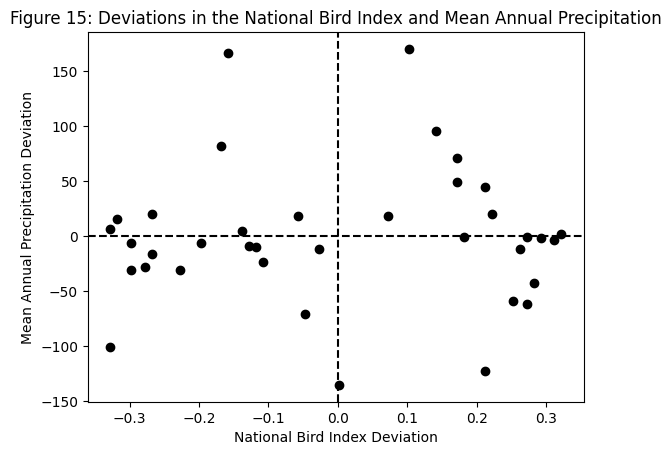

In [29]:
#calculate deviations for x and y variables
#x=bird, y=prec_1985, xb=bird deviation, yp=prec_1985 deviation

yp = prec_1985 - np.mean(prec_1985) #deviation in the y variable
plt.plot(xb , yp, 'ok') #plot deviations
plt.gca().axvline(x=0, color = 'k', linestyle = '--') #add a vertical line at x=0
plt.gca().axhline(y=0, color = 'k', linestyle = '--') #add a horizontal line at y=0
plt.xlabel('National Bird Index Deviation')
plt.ylabel('Mean Annual Precipitation Deviation')
plt.title('Figure 15: Deviations in the National Bird Index and Mean Annual Precipitation')
plt.show()

### *Figure 15: Deviations in the National Bird Index and Mean Annual Precipitation*

Figure 15 shows the deviations in the National Bird Index and Mean Annual Precipitation. Observation suggests a relationship between the two variables is unclear, or at least less significant than the relationship between the National Bird Index and Mean Annual Temperature.

 ### Sample Pearson's r and P-Value for Mean Annual Precipitation and National Bird Index Relationship

In [30]:
#equation to find pearson's correlation coefficient = r
num2 = np.sum(xb * yp) #find the numerator
den2 = np.sqrt(np.sum(xb**2)) * np.sqrt(np.sum(yp**2)) #find the denominator
r2 = num2/den2 #obtain r
print('Sample Pearsons r = {:.2f}'.format(r2)) #print result to 2 d.p.
print('squared r = {:.2f}'.format(r2**2)) #print result to 2 d.p.

Sample Pearsons r = 0.02
squared r = 0.00


In [31]:
# Calculate the Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(bird, prec_1985)

print(f"Pearson Correlation Coefficient between Normalized Bird Index and Annual Mean Temperature: {correlation_coefficient:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

Pearson Correlation Coefficient between Normalized Bird Index and Annual Mean Temperature: 0.02
P-value: 0.897
The correlation is not statistically significant.


### Calculating Rho, the Covariance Matrix and 95% HDI for Correlation Coefficient

In [32]:
## combining bird and prec_1985 into a matrix (two-dimensional dataset) so it can be modelled

xbyp = np.column_stack([bird, prec_1985])

with pm.Model() as model: #define the PyMC model

    # Priors for means of the bivariate normal distribution
    mu2 = pm.Normal("mu2", mu=0, sigma=5, shape=2)
    ## mean of x = 0, sd of x = 5, shape = we need two priors, one for x and one for y

    # Prior for correlation coefficient — uniform between -1 and 1
    rho2 = pm.Uniform("rho2", lower=-1, upper=1)

    # Prior for standard deviations of the bivariate normal distribution
    sigma2 = pm.HalfNormal("sigma2", sigma=2, shape=2, progressbar=False)
    ## half normal only allows the positive distributions (standard deviations must be positive)

    # Build the covariance matrix from rho and sigmas (priors)
    cov2 = pm.math.stack(
        [
            [sigma2[0]**2, rho2 * sigma2[0] * sigma2[1]],
            [rho2 * sigma2[0] * sigma2[1], sigma2[1]**2]
        ]
    )

    # Likelihood is a "multivariate" (in this case bivariate) normal distribution
    obs2 = pm.MvNormal("obs2", mu=mu2, cov=cov2, observed=xbyp, progressbar=False)

    # Obtain 5000 samples from the posterior distributions (mu, rho, & sigma)
    trace2 = pm.sample(sample=5000, progressbar=False)

In [35]:
# Calculate the 95% HDI for 'rho2'
hdi_rho_p = az.hdi(trace2, var_names=["rho2"], prob=0.95)

print(f"95% HDI for rho2: {hdi_rho_p['rho2'].values}")

95% HDI for rho2: [-0.28858399  0.34408622]


The calculations show the 95% HDI for rho2 is [-0.288, 0.344].

The 95% HDI band for rho2 *does* include 0, indicating the **correlation is not statistically significant**. This reinforces the earlier Sample Pearson's $r$ correlation result which showed **no statistically significant relationship (p-value of 0.897)**.

### Correlation Analysis for National Bird Index and Annual Mean Precipitation
- There is an extremely weak positive linear relationship (0.02) between the National Bird Index and Annual Mean Precipitation.
- Less than 1% of the variability in the National Bird Index is explained by Annual Mean Precipitation, suggesting a variety of factors outside of rainfall are influencing the National Bird Index.
- The sample P-value (0.897) shows the relationship is **not statistically significant**.

- The 95% HDI for rho2 (population correlation coefficient) includes 0, indicating the correlation is also **not statistically significant**.
  - **There is no significant relationship between the National Bird Index and Annual Mean Precipitation**.

---

# Discussion

### Key Findings from the Analysis

1.  **The local Superb Fairy-wren population at the ANBG is exponentially declining, indicating the population will become extinct.**

Figure 3 illustrates the raw average Fairy-wren population decline over time. This decline is further supported by Figure 6, which shows a linear negative trend when the population data is logged, confirming an exponential decay. The regression model in Figure 7 visually confirms this exponential decline, aligning with the predictions of the Lv et al. paper that Superb Fairy-wrens will become extinct.

2.  **The National Bird Index is not inconsistent with local FW population trends, because the Index falls within the predictive 95% HDI for local FW population size.**

Figure 4 provides a visual comparison of the normalised National Bird Index and the average Fairy-wren population, suggesting similar trends. This consistency is statistically evaluated in Figure 7, where the scaled National Bird Index falls within the 95% Highest Density Interval (predictive) band of the Fairy-wren population regression model. This indicates that while not definitively 'consistent' due to sample size, the trends are not contradictory.

This is significant because Fairy-wrens are categorised as a species of Least Concern by the IUCN, who cite the species population as Stable. Results from the regression model and overlayed National Bird Index show that this species of Least Concern displays trends that are not inconsistent with nationally-recognised Threatened and Near-Threatened bird species. This is a concerning result for bird species (and other less-cool animals) across Australia! The result could be demonstrative of Australia's wider biodiversity crisis, where Non-Threatened and extremely common species could come under severe extinction threat due to a variety of compounding climate change factors.

3.  **Mean Annual Temperatures and the National Bird Index have a statistically significant relationship, demonstrating a negative linear relationship.**

Figure 8 shows a clear warming trend in Australia's mean annual temperatures over the long term. Figure 12 visually suggests a negative linear relationship between the National Bird Index and Mean Annual Temperature. The Pearson's r value of -0.50 confirms a moderate negative linear correlation, and the p-value of 0.002 indicates statistical significance. The 95% HDI for rho, which does not include zero, further supports this finding.

This is a significant finding because the Lv et al. paper suggested Fairy-wren extinction due to a variety of small, but compounding climate change impacts. The correlation analysis proves a significant relationship between relative bird species abundance in Australia and rising average temperatures. Increasing temperature is a key indicator of climate change, and this result is illustrative of the death-by-a-thousand-cuts future awaiting us in the face of climate change (depressing).

Temperatures are increasing. This sustained increase in average temperatures identified using moving averages (Figure 10) could be a foundational factor contributing to the observed decline in both the national bird index and the Fairy-wren population during the more recent period.

4.  **Mean Annual Precipitation and the National Bird Index do not have a significant relationship.**

There was no significant relationship identified between Mean Annual Precipitation and the National Bird Index, unlike the relationship found with Mean Annual Temperature. These findings suggest that, at a national scale and over this 37-year period, annual mean precipitation does not appear to be a significant driver of changes in the National Bird Index. This might be due to the complex and varied precipitation patterns across Australia, where local effects might be significant, but a broad national average does not capture a direct, overarching impact on bird species abundance.


---

### Addressing the Research Questions

1. Is the local population of Superb Fairy-wrens at the ANBG trending towards extinction?
* Yes (sadly).
2. Are local FW population trends aligned or consistent with national abundance of threatened and near-threatened bird species (National Bird Index)?
* FW population trends are not inconsistent with the National Bird Index.
3. Is there a relationship between climate variables like temperature and rainfall (climate change signifiers) and national bird species abundance?
* Temperature and National Bird Index - statistically significant, negative linear trend. Precipitation and National Bird Index - not statistically significant, no identifiable trend.
4. What inferences can we make about Australian bird species abundance and population trends from this analysis?
* *Maybe*, everything's going down hill towards extinction? The analysis illustrates the severity of Australia's current biodiversity crisis, where national and local bird species abundance levels are declining.

---

# Limitations

The local FW population at the ANBG in Canberra is a very small sample size, which was extrapolated to make inferences about the entire species' population. Drawing direct comparisons from this small sample size to national taxon-based trends is a key limitation of this project, as comparisons may be inaccurate.

Constantly scaling, re-scaling and normalising the National Bird Index could have lead to inconsistencies in the analysis, although the results still proved significant.

Ties between the FW population data and Climate Variable analysis was not conducted - could not find appropriate data, and ran out of time.

There were several issues trying to plot the posterior samples and 95% HDI for the National Bird Index-Mean Annual Temperature Correlation Coefficient. Had to go without plotting posteriors and printed HDI instead. Additionally, the arviz package also threw a lot of issues while trying to conduct analysis.

---

# Conclusion

Using the analysis techniques regression, timeseries and correlation, I successfully investigated findings from the Lv et al. paper, which claimed that the Superb Fairy-wren would go extinct soon due to a variety of climate change impacts.

My analysis found that current population trends of FWs at the Australian National Botanic Gardens was exponentially decaying, suggesting this local population will go extinct.

This trend was not inconsistent with national declining abundance trends of Threatened and Near-Threatened bird species in Australia. This is an interesting/concerning result considering the FW's status as Least Concern.

By investigating climate variables such as temperature and rainfall, a statistically significant relationship was found between the National Bird Index and Mean Annual Temperatures. The relationship shows increasing annual temperatures and decreasing National Bird Index scores, particularly from 2013-present.

All analysis from this project supports the findings of the [Lv. et al.](https://www.nature.com/articles/nature01096) paper.